# Config

## Imports

In [1]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(module)s.%(funcName)s(): %(message)s"
)
logger = logging.getLogger(__name__)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from typing import Optional, List
from pathlib import Path

from fjsspw_solver import (
    Individual,
    Encoding,
)
from fjsspw_solver.genetic_algorithm import (
    Method,
    MethodParams,
)
from fjsspw_solver.operators import (
    Selections,
    Crossovers,
    Mutations,
    CrossoverParams,
    SelectionParams,
    MutationParams,
)
from fjsspw_solver.plotting import (
    plot_fjsspw_gantt,
    plot_learning_progress,
)

from util.benchmark_parser import WorkerBenchmarkParser
from util.uncertainty import create_uncertainty_vector
from util.graph import Graph

PROD = False

## Instances setup

In [2]:
instance_data_path = Path("instances/SelectedInstanceData/selected_instances_data.csv")
instance_data = pd.read_csv(instance_data_path)
instance_data_groupped = instance_data.groupby("type")
instance_data

,source,n_operations,flexibility,duration_variety,n_machines,n_jobs,average_operations_per_job,d_max,d_min,d_distinct,d_unique,d_shared,d_average,n_worker,type
0,Hurinkvdata55,49,0.259184,0.595051,7,7,7.00,1054,2,529,313,216,485.680540,10,small
1,Fattahi9,9,0.416667,0.755556,3,3,3.00,108,16,34,25,9,55.822222,4,small
2,BrandimarteMk6,150,0.171200,0.002596,10,10,15.00,10,1,10,0,10,5.010903,15,medium
3,Hurinkvdata28,150,0.261956,0.017645,10,15,10.00,109,5,104,0,104,49.427044,15,medium
4,ChambersBarnes10,150,0.056086,0.050048,13,15,10.00,109,5,104,2,102,54.177093,19,medium
5,Hurinksdata34,300,0.055133,0.041516,10,30,10.00,107,5,103,0,103,50.275292,15,large
6,Hurinkedata34,300,0.058489,0.039514,10,30,10.00,108,5,104,1,103,52.518997,15,large
7,Hurinkrdata34,300,0.103933,0.022236,10,30,10.00,108,5,104,2,102,51.367329,15,large
8,Hurinkvdata34,300,0.240244,0.009620,10,30,10.00,108,5,104,0,104,52.294515,15,large
9,Behnke20,500,0.163787,0.000509,20,100,5.00,33,9,25,0,25,20.032563,30,dense


In [3]:
parser = WorkerBenchmarkParser()
instance_name = 'Fattahi10'
instance_path = Path(f'instances/Example_Instances_FJSSP-WF/{instance_name}.fjs')
encoding = parser.parse_benchmark(str(instance_path))

In [4]:
encoding = Encoding(encoding.durations(), encoding.job_sequence())

method_params = MethodParams(
    generations=10,
    population_size=10,
    selection_params=SelectionParams(
        size=10,
        selection=Selections.ROULETTE,
    ),
    crossover_params=CrossoverParams(
        crossover_prob=0.3,
        crossover=Crossovers.POX,
    ),
    mutation_params=MutationParams(
        mutation_prob=0.2,
        mutation=Mutations.GENE_SWAP,
    ),
    fitness_fun_evals_per_indv=3,
    instance_name=instance_name,
)

uncertainty_parameters = create_uncertainty_vector(encoding.n_operations(), factor=10.0, offset=1.0)

In [5]:
def uncertain_eval_function(indv: Individual, iters: int = 1) -> List|float:
    _, machines, workers, start_times, end_times = indv.get_representation()
    logger.debug(f"machines={machines}"
                 f", workers={workers}"
                 f", job_sequence={encoding.get_job_sequence()}"
                 f", start_times={start_times}"
                 f", end_times={end_times}")
    fitnesses = [0] * iters
    for i in range(iters):
        g = Graph(start_times, end_times, machines, workers, encoding.get_job_sequence())
        g.simulate(encoding.get_durations(), uncertainty_parameters, processing_times=True)
        fitnesses[i] = max(g.e)
    return fitnesses if iters > 1 else fitnesses[0]

# Sanity check

## Run method

In [19]:
logger.info("Init method")
method = Method(method_params, encoding, uncertain_eval_function)
logger.info("Finish init method")

2026-03-25 22:17:55,689 [INFO] 3011316685.<module>(): Init method
2026-03-25 22:17:55,697 [INFO] 3011316685.<module>(): Finish init method


In [20]:
best_indv = method.solve()

2026-03-25 22:17:55,710 [INFO] genetic_algorithm.perform_generation(): Optimization run #0 ongoing...
2026-03-25 22:17:55,711 [INFO] genetic_algorithm.perform_generation(): Finished in 0.008877200001734309 ms
2026-03-25 22:17:55,711 [INFO] genetic_algorithm.perform_generation(): Optimization run #1 ongoing...
2026-03-25 22:17:55,726 [INFO] genetic_algorithm.perform_generation(): Finished in 0.006581200002983678 ms
2026-03-25 22:17:55,726 [INFO] genetic_algorithm.perform_generation(): Optimization run #2 ongoing...
2026-03-25 22:17:55,732 [INFO] genetic_algorithm.perform_generation(): Finished in 0.00646940000297036 ms
2026-03-25 22:17:55,732 [INFO] genetic_algorithm.perform_generation(): Optimization run #3 ongoing...
2026-03-25 22:17:55,732 [INFO] genetic_algorithm.perform_generation(): Finished in 0.0053444999939529225 ms
2026-03-25 22:17:55,740 [INFO] genetic_algorithm.perform_generation(): Optimization run #4 ongoing...
2026-03-25 22:17:55,747 [INFO] genetic_algorithm.perform_gener

## Evaluate

In [21]:
sequence, machines, workers, start_times, end_times = best_indv.get_representation()
sequence, machines, workers, start_times, end_times

([1, 3, 1, 2, 3, 1, 0, 2, 2, 3, 0, 0],
 [0, 1, 3, 2, 1, 4, 0, 2, 4, 0, 4, 2],
 [3, 5, 6, 2, 1, 1, 3, 0, 3, 5, 2, 4],
 [184, 343, 464, 0, 142, 327, 90, 184, 513, 0, 142, 358],
 [343, 464, 627, 142, 205, 513, 184, 358, 617, 90, 327, 493])

In [22]:
if PROD:
    assert len(sequence) > 0, "The sequence should not be empty."
    assert len(machines) > 0, "The number of machines should not be empty."
    assert len(workers) > 0, "The number of workers should not be empty."
    assert len(start_times) > 0, "The number of start_times should not be empty."
    assert len(end_times) > 0, "The number of end_times should not be empty."

In [23]:
# start_times, machines, workers = evaluation.translate(sequence, machines, workers, encoding.get_durations()) # necessary because the solver does not provide the start times of the schedule
# c = evaluation.makespan(start_times, machines, workers, encoding.get_durations())
c = best_indv.get_internal_fitness()
robust_c = uncertain_eval_function(best_indv)
print(f'Makespan: {c}')
print(f'Robust makespan: {robust_c}')

Makespan: 627
Robust makespan: 1292.3736632243977


## Plot results

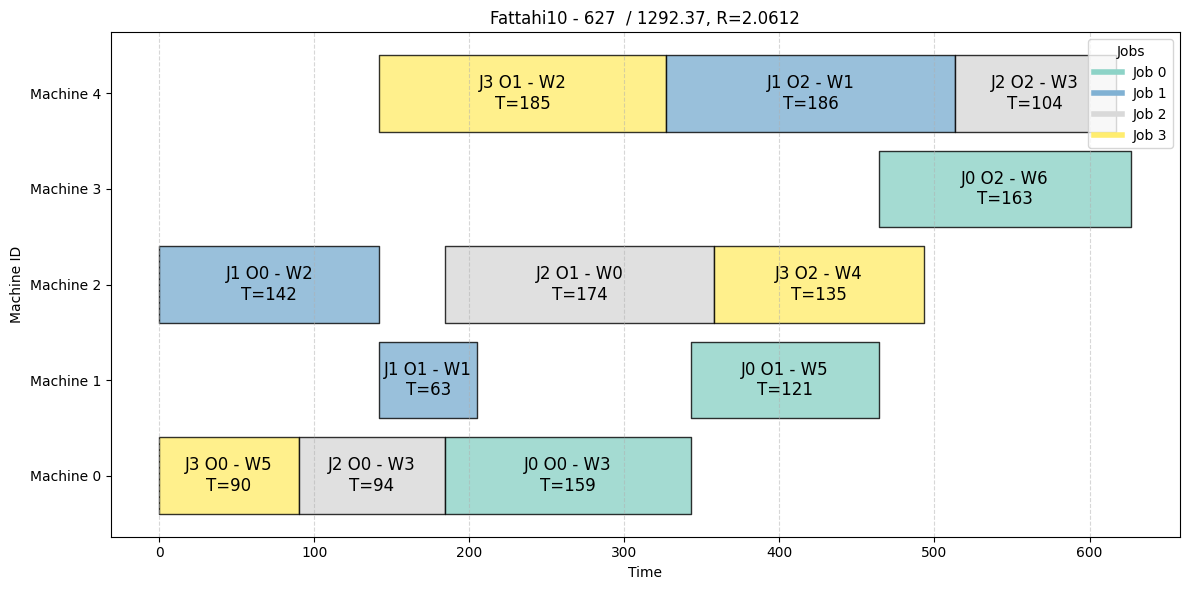

In [24]:
plot_fjsspw_gantt(sequence, machines, workers, start_times, end_times, encoding=encoding, instance_name=instance_name, c=c, robust_c=robust_c)

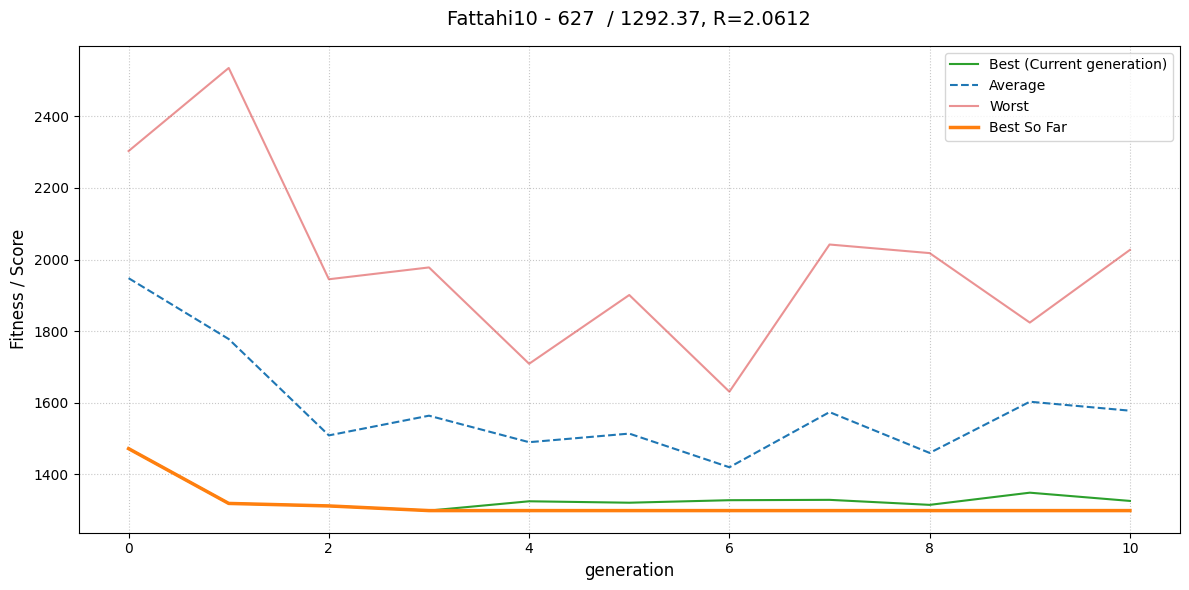

In [25]:
plot_learning_progress(method.get_log_file_path(), instance_name=instance_name, c=c, robust_c=robust_c)

# Experiments

## Imports

In [6]:
from pprint import pprint

## Instance setup

In [18]:
base_method_params = MethodParams.from_file(Path('./config/method.cfg'))

parser = WorkerBenchmarkParser()
instance_name = base_method_params.instance_name

encoding = parser.parse_benchmark(f'instances/Example_Instances_FJSSP-WF/{instance_name}')
encoding = Encoding(encoding.durations(), encoding.job_sequence())

uncertainty_parameters = create_uncertainty_vector(encoding.n_operations(), factor=10.0, offset=1.0)

In [19]:
def uncertain_eval_function(indv: Individual, iters: int = 1) -> List|float:
    _, machines, workers, start_times, end_times = indv.get_representation()
    logger.debug(f"machines={machines}"
                 f", workers={workers}"
                 f", job_sequence={encoding.get_job_sequence()}"
                 f", start_times={start_times}"
                 f", end_times={end_times}")
    fitnesses = [0] * iters
    for i in range(iters):
        g = Graph(start_times, end_times, machines, workers, encoding.get_job_sequence())
        g.simulate(encoding.get_durations(), uncertainty_parameters, processing_times=True)
        fitnesses[i] = max(g.e)
    return fitnesses if iters > 1 else fitnesses[0]

In [24]:
def evaluate_method_with_params(params: MethodParams, encoding: Encoding):
    method = Method(params, encoding, uncertain_eval_function)
    best_indv = method.solve()
    best_solution = best_indv.get_representation()
    
    print(best_indv.to_string())
    
    c = best_indv.get_internal_fitness()
    robust_c = uncertain_eval_function(best_indv)
    
    plot_fjsspw_gantt(*best_solution, encoding=encoding, instance_name=params.instance_name, c=c, robust_c=robust_c)
    plot_learning_progress(method.get_log_file_path(), instance_name=params.instance_name, c=c, robust_c=robust_c)

In [21]:
pprint(base_method_params)

Pretty printing has been turned OFF


## from config

2026-03-25 22:26:12,635 [INFO] genetic_algorithm.perform_generation(): Optimization run #0 ongoing...
2026-03-25 22:26:12,754 [INFO] genetic_algorithm.perform_generation(): Finished in 0.11738180000247667 ms
2026-03-25 22:26:12,754 [INFO] genetic_algorithm.perform_generation(): Optimization run #1 ongoing...
2026-03-25 22:26:12,877 [INFO] genetic_algorithm.perform_generation(): Finished in 0.11778230000345502 ms
2026-03-25 22:26:12,877 [INFO] genetic_algorithm.perform_generation(): Optimization run #2 ongoing...
2026-03-25 22:26:12,982 [INFO] genetic_algorithm.perform_generation(): Finished in 0.11657620000187308 ms
2026-03-25 22:26:12,982 [INFO] genetic_algorithm.perform_generation(): Optimization run #3 ongoing...
2026-03-25 22:26:13,107 [INFO] genetic_algorithm.perform_generation(): Finished in 0.1188114000033238 ms
2026-03-25 22:26:13,114 [INFO] genetic_algorithm.perform_generation(): Optimization run #4 ongoing...
2026-03-25 22:26:13,225 [INFO] genetic_algorithm.perform_generation

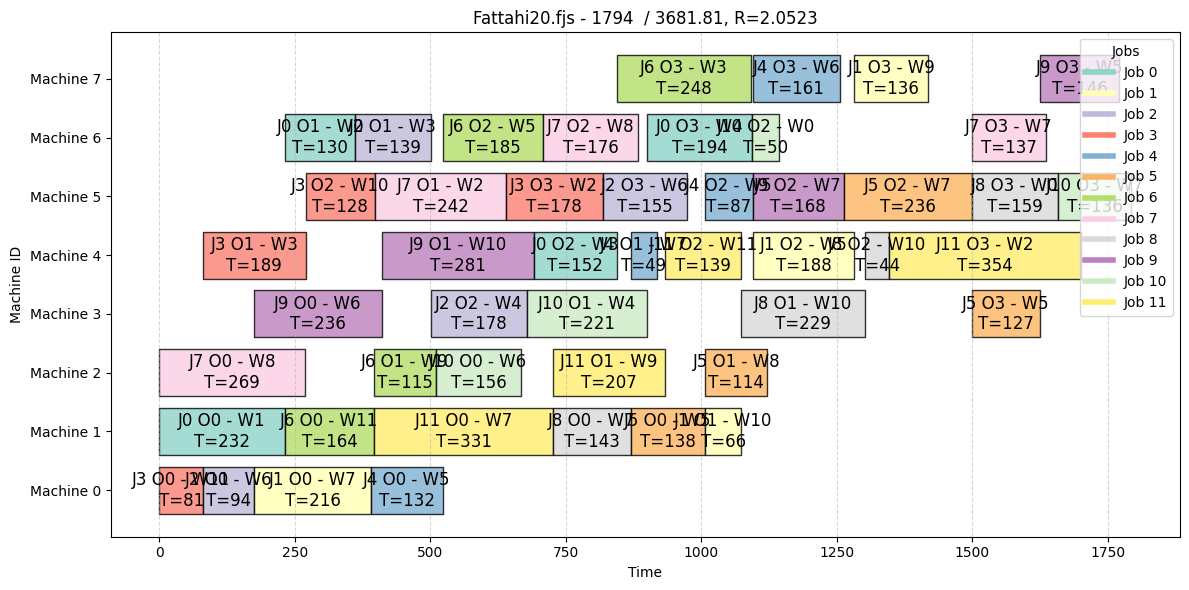

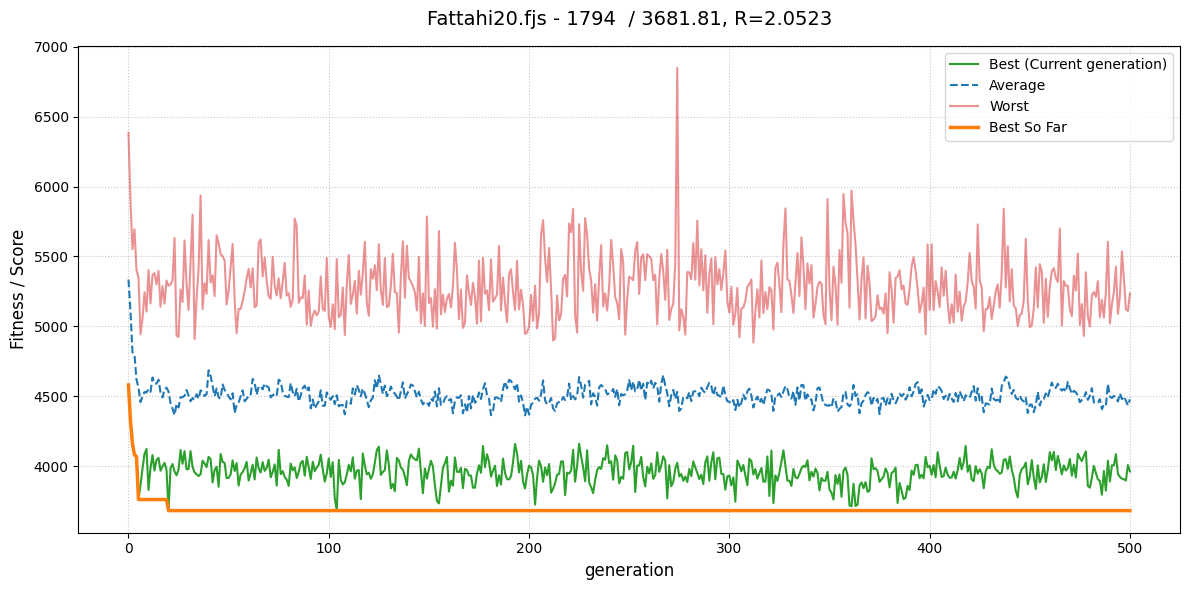

In [22]:
evaluate_method_with_params(base_method_params, encoding)

In [23]:
print("sequence", best_indv.sequence)
print("machines", best_indv.machines)
print("workers", best_indv.workers)

NameError: name 'best_indv' is not defined

## generations=100, Pop=10, Indv_evals=3

In [26]:
from copy import copy


method_params_3 = copy(base_method_params)
method_params_3 = MethodParams(
    generations=100,
    population_size=10,
    selection=Selections.TOURNAMENT,
    crossover=Crossovers.POX,
    mutation=Mutations.GENE_SWAP,
    fitness_fun_evals_per_indv=3,
    instance_name=instance_name,
)

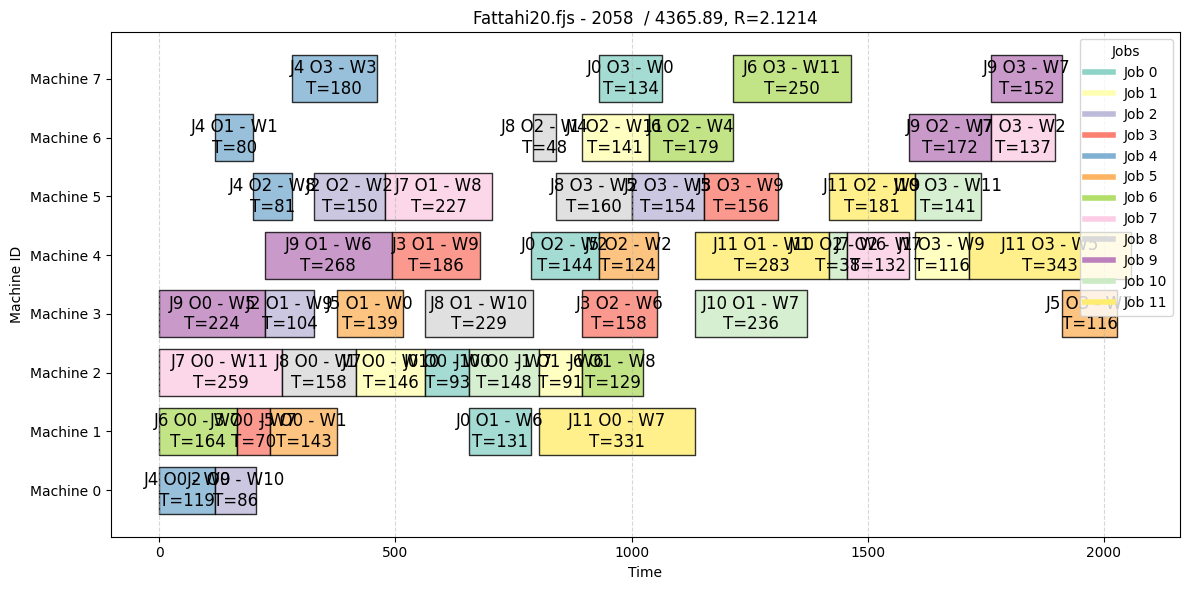

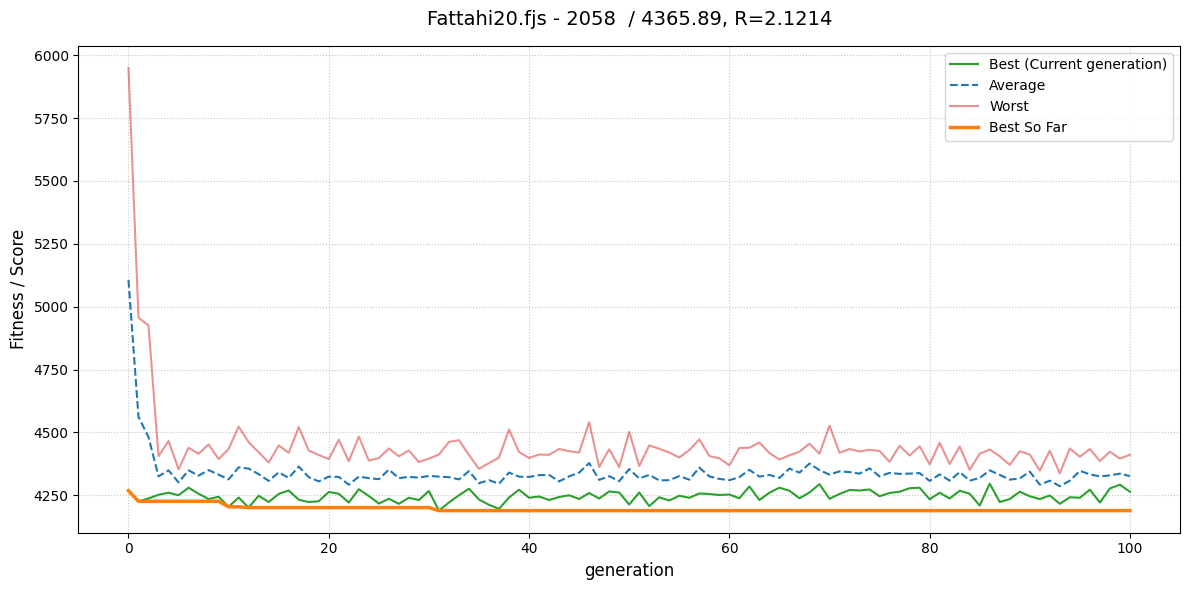

In [27]:
evaluate_method_with_params(method_params_3, encoding)

## generations=100, Pop=10, Indv_evals=5

In [28]:
method_params_5 = MethodParams(
    generations=100,
    population_size=10,
    selection=Selections.TOURNAMENT,
    crossover=Crossovers.POX,
    mutation=Mutations.GENE_SWAP,
    fitness_fun_evals_per_indv=5,
    instance_name=instance_name,
)

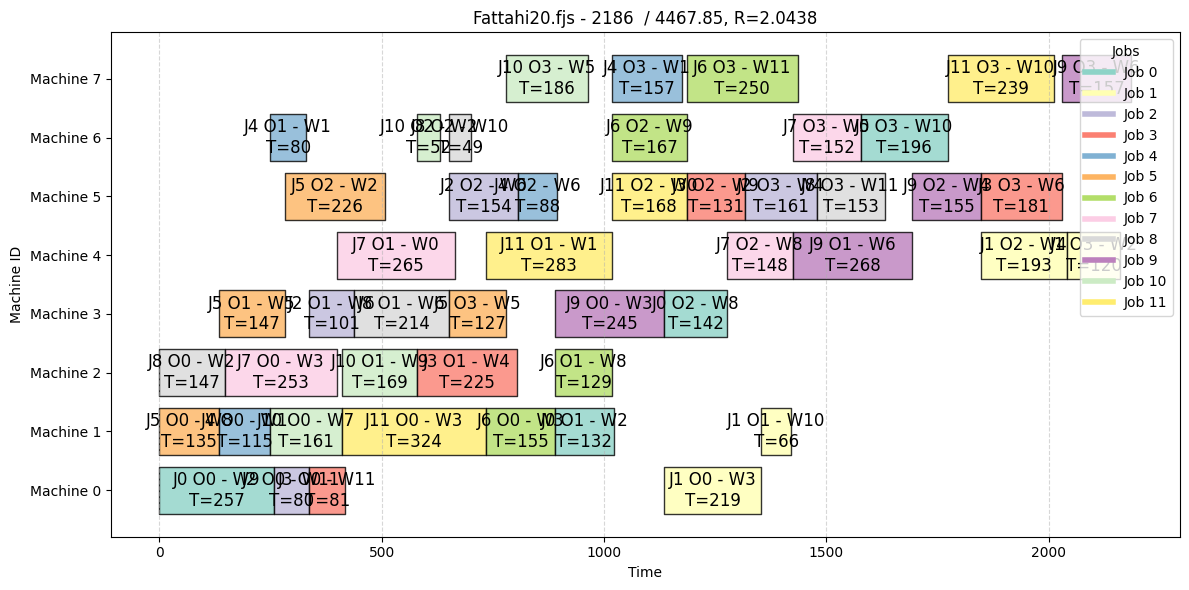

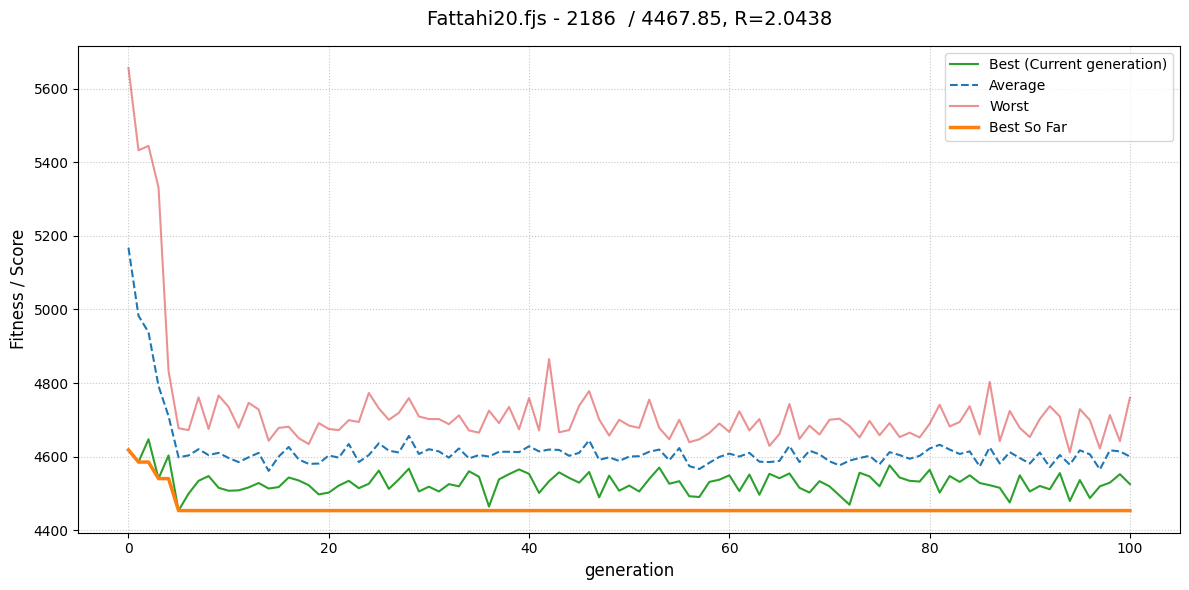

In [29]:
evaluate_method_with_params(method_params_5, encoding)

## generations=100, Pop=20, Indv_evals=3

In [30]:
method_params_3_20 = MethodParams(
    generations=100,
    population_size=20,
    selection=Selections.TOURNAMENT,
    crossover=Crossovers.POX,
    mutation=Mutations.GENE_SWAP,
    fitness_fun_evals_per_indv=5,
    instance_name=instance_name,
)

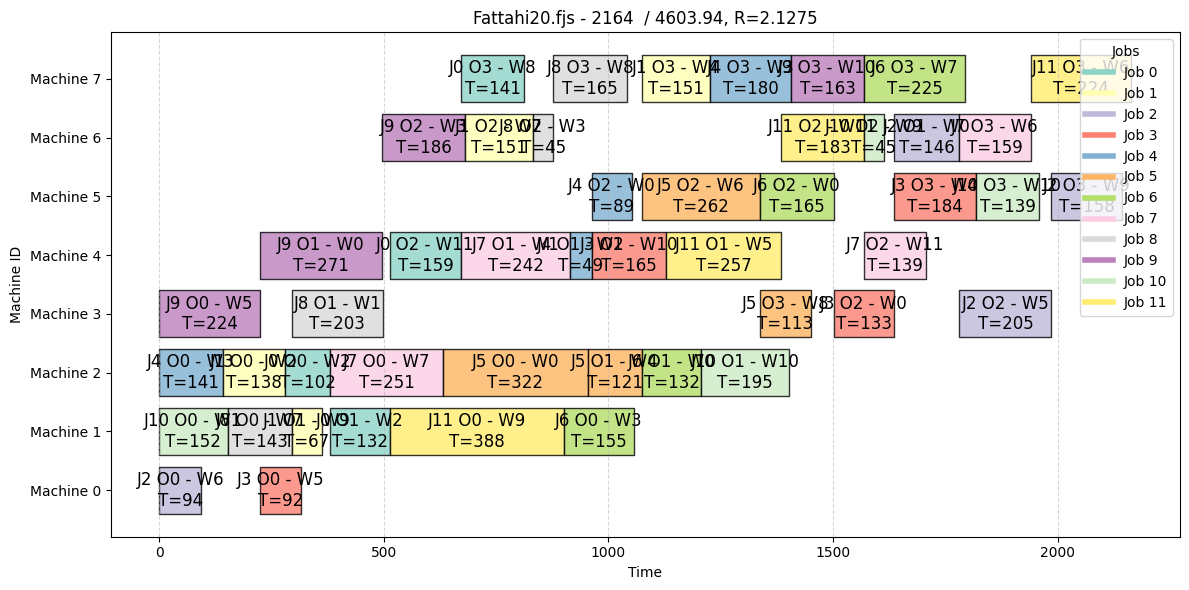

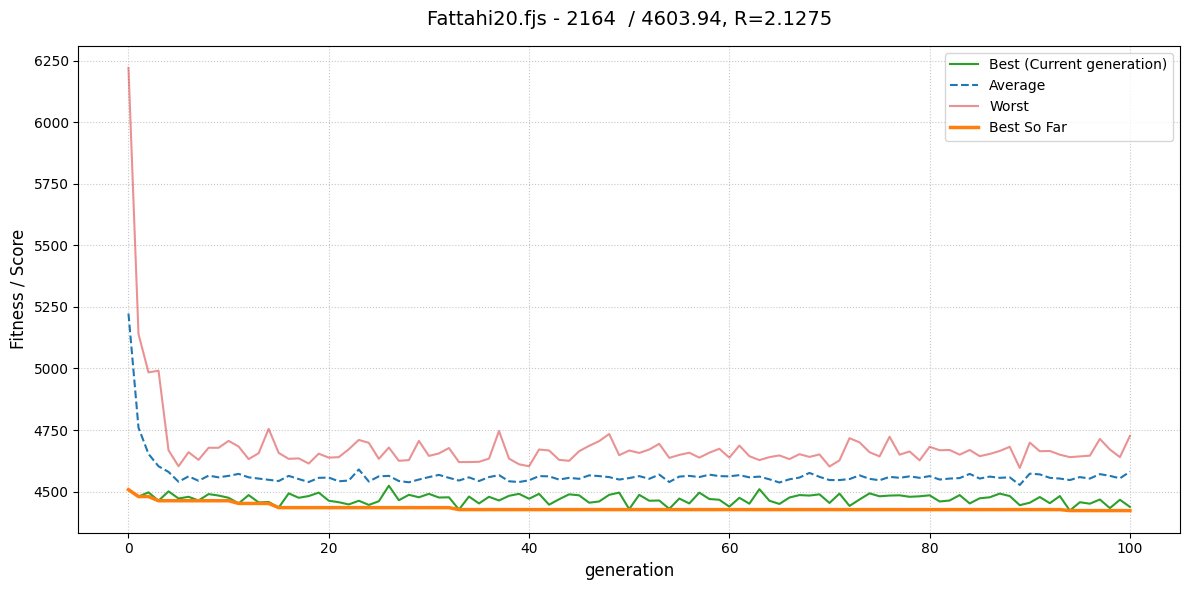

In [31]:
evaluate_method_with_params(method_params_3_20, encoding)

## generations=100, Pop=25, Indv_evals=3

In [32]:
method_params_3_25 = MethodParams(
    generations=100,
    population_size=20,
    selection=Selections.TOURNAMENT,
    crossover=Crossovers.POX,
    mutation=Mutations.GENE_SWAP,
    fitness_fun_evals_per_indv=5,
    instance_name=instance_name,
)

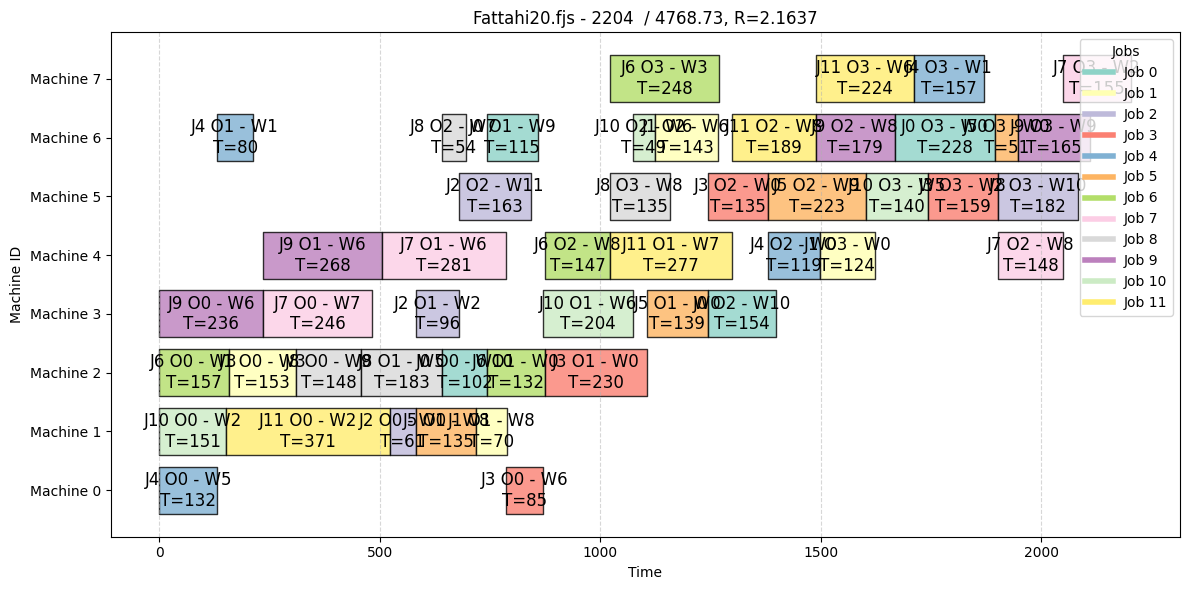

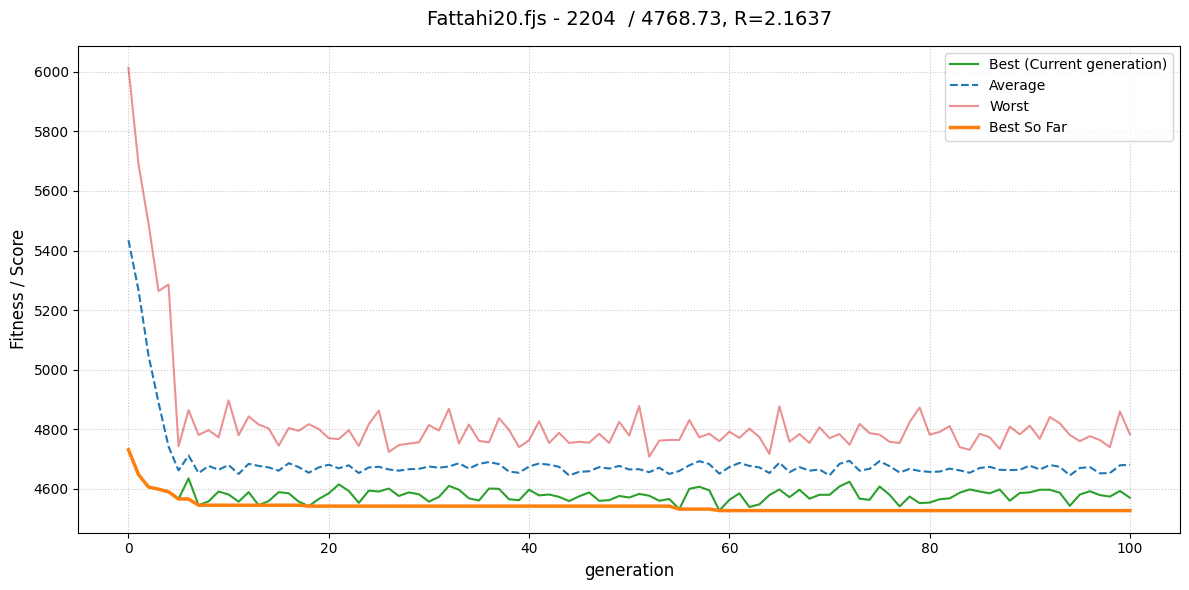

In [33]:
evaluate_method_with_params(method_params_3_25, encoding)